<h1 style="text-align:center;">Market impact modelling : Almgen Chriss</h1>

## Sumary :

* [**1.Theory and principal results**](#0)
* [**2.Importation of data**](#1)
* [**3.Model calibration : Construction of estimators**](#2)
* [**4.Almgren-Chriss implementation**](#3)
* [**5.Application**](#3)

In [110]:
import pandas_datareader.data as web
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
from dataclasses import dataclass, field
from typing import Tuple

<a id='0'></a>
# 1. Theory and principal results :


Source : [Almgren–Chriss paper](https://www.smallake.kr/wp-content/uploads/2016/03/optliq.pdf)


---

### Notations :

- $X$ : number of shares we have to liquidate 
- $T$ : time before we have to liquidate
- $N$ : number of intervals $\implies \tau = \frac{T}{N}$ 
- $(x_k)_{k \in \{0, \cdots, N\}}$ : quantity of stocks at time $t_k$, we take $x_k = (N-k) \cdot \frac{X}{N}$
- $(n_k)_{k \in \{0, \cdots, N\}}$ :  trade list, we take $n_k = \frac{X}{N}$


---

### General mid-price model with linear permanent impact :

$$
\boxed{
S_k = S_{k-1} + \sigma \tau ^{\frac{1}{2}} \xi_k - \gamma \cdot  \frac{X}{N}
}
$$

**With assumptions :**

- $\sigma$ : volatility of $S$
- $\xi \sim N(0,1)$ : noise of market
- $\gamma$ : constant parameter of impact permanent function
- $\frac{X}{N \cdot \tau}$ : represent the speed of trading

---

### General buy / sell price model with linear permanent impact :

$$
\boxed{
\tilde{S_k} = S_{k-1} - \epsilon \cdot sgn(\frac{X}{N}) -  \frac{\eta \cdot X}{T}
}
$$

**With assumptions :**

- $sgn(\frac{X}{N})$ : instant impact
- $\frac{\eta}{\tau} \cdot \frac{X}{N}$ : linear temporary impact

- $\eta$ : constant parameter of temporary impact function
- $\epsilon$ : constant parameter of instant impact

---

### General results of the model :

We denote by $x = X \cdot S_0 - \sum_{k=1}^{N} \frac{X}{N}\,\tilde{S}_k$ the execution cost of the strategy.

$$
\boxed{
E[x] = \frac{1}{2} \gamma X^2 + \epsilon X + (\eta - \frac{1}{2} \gamma \tau) \frac{X^2}{T}
}
$$

$$
\boxed{
V[x] = \frac{1}{3} T \sigma ^2 X^2 (1 - \frac{1}{N})(1 - \frac{1}{2N})
}
$$

---

### Optimal strategie problem :

$$
\boxed{
\min_{x}\ \mathbb{E}[x]
\quad \text{s.t.} \quad
\mathrm{Var}(x) \le V^*
}
$$


**Solution :**


$$
\boxed{
x_j^* =
X \frac{\sinh\!\big(\kappa (T - t_j)\big)}{\sinh(\kappa T)}
}
\qquad
\boxed{
n_j^* = x_{j-1}^* - x_j^*
}
$$

Avec :


- $\kappa^2 = \frac{\lambda \sigma^2}{\eta - \frac{1}{2} \cdot \gamma \cdot \tau}$

- $t_j = j\tau$

- $\tau = \frac{T}{N}$


<a id='1'></a>
# 2. Importation of data :

In [111]:
######################################### 
########### Données y-finance ###########
#########################################
ticker = "AAPL"

df = yf.download(
    ticker,
    interval="1m",
    period="7d",
    progress=False
)

<a id='2'></a>
# 3. Model calibration :

## Construction of Estimators

---

### Dynamics of $m_t$ (Mid-Price Proxy)

We approximate the mid price as

$$
m_t = \frac{H_t + L_t}{2}
$$

where:

- $H_t$ : High price at time $t$
- $L_t$ : Low price at time $t$

---

### Dynamics of $q_t$ (Signed Volume Proxy)

We define the signed traded volume at time $t$ as

$$
q_t = \operatorname{sign}(C_t - C_{t-1}) \cdot V_t
$$

where:

- $C_t$ is the closing price at time $t$,
- $V_t$ is the traded volume during period $t$,
- $\operatorname{sign}(x)$ is the sign function.

This quantity is a proxy for the **net buying or selling pressure** of the market during period $t$.

---

### Estimator of $\gamma$ (Permanent Impact)

By considering $m_t \approx S_t$ and $q_t$ as a proxy for the market order flow,  
we model the permanent price impact as

$$
\Delta m_{k+1} = \gamma\, q_k + \varepsilon_k,
\qquad
\mathbb{E}[\varepsilon_k \mid q_k] = 0.
$$

The Ordinary Least Squares (OLS) estimator of $\gamma$ without intercept is

$$
\boxed{
\hat{\gamma}
=
\frac{\sum_{k=0}^{N-1} q_k \, \Delta m_{k+1}}
     {\sum_{k=0}^{N-1} q_k^2}
}.
$$

---

### Estimator of $\eta$ (Temporary Impact)

We use the intraminute price range as a proxy for temporary impact:

$$
R_k := H_k - L_k.
$$

We relate this range to the trading intensity measured by the absolute signed volume proxy $|q_k|$:

$$
R_k = \eta\,|q_k| + u_k,
\qquad
\mathbb{E}[u_k \mid q_k] = 0.
$$

The Ordinary Least Squares (OLS) estimator of $\eta$ without intercept is

$$
\boxed{
\hat{\eta}
=
\frac{\sum_{k=0}^{N-1} |q_k|\,R_k}
     {\sum_{k=0}^{N-1} |q_k|^2}
}.
$$

In [112]:
#########################################
######## Construction estimateurs #######
#########################################
def calibration(High, Low, Close, Volume):
    """
    Calibrate Almgren–Chriss impact parameters (gamma, eta, sigma)
    from OHLCV time series.

    Inputs
    ------
    High   : pandas Series
    Low    : pandas Series
    Close  : pandas Series
    Volume : pandas Series

    Outputs
    -------
    gamma : float
        OLS slope in: Δm_{t+1} = gamma * q_t + eps_t

    eta : float
        OLS slope in: R_t = eta * |q_t| + u_t

    sigma : float
        empirical std of Δm_{t+1} / tau^{1/2}
    """

    # ---------------------------------------------------------------------
    # Time series proxies
    # ---------------------------------------------------------------------
    mid_price_proxy     = (High + Low) / 2
    signed_volume_proxy = np.sign(Close.diff()) * Volume
    range_price_proxy   = High - Low

    # ---------------------------------------------------------------------
    # GAMMA (permanent impact): Δm_{t+1} vs q_t
    # ---------------------------------------------------------------------
    delta_mid_price_proxy = mid_price_proxy.shift(-1) - mid_price_proxy

    x_gamma = signed_volume_proxy
    y_gamma = delta_mid_price_proxy

    # Remove outliers (gamma)
    qx_low, qx_high = x_gamma.quantile([0.01, 0.99])
    qy_low, qy_high = y_gamma.quantile([0.01, 0.99])

    mask_out = (
        (x_gamma > qx_low) & (x_gamma < qx_high) &
        (y_gamma > qy_low) & (y_gamma < qy_high)
    )

    x_gamma_clean = x_gamma[mask_out]
    y_gamma_clean = y_gamma[mask_out]

    denom_gamma = np.sum(x_gamma_clean**2)
    gamma = np.sum(x_gamma_clean * y_gamma_clean) / denom_gamma if denom_gamma != 0 else 0.0

    # ---------------------------------------------------------------------
    # ETA (temporary impact proxy): range vs |q_t|
    # ---------------------------------------------------------------------
    x_eta = np.abs(signed_volume_proxy)
    y_eta = range_price_proxy

    # Remove outliers (eta)
    qx_low_e, qx_high_e = x_eta.quantile([0.01, 0.99])
    qy_low_e, qy_high_e = y_eta.quantile([0.01, 0.99])

    mask_out_eta = (
        (x_eta > qx_low_e) & (x_eta < qx_high_e) &
        (y_eta > qy_low_e) & (y_eta < qy_high_e)
    )

    x_eta_clean = x_eta[mask_out_eta]
    y_eta_clean = y_eta[mask_out_eta]

    denom_eta = np.sum(x_eta_clean**2)
    eta = np.sum(x_eta_clean * y_eta_clean) / denom_eta if denom_eta != 0 else 0.0

    # ---------------------------------------------------------------------
    # Sigma : vol (price increments)
    # ---------------------------------------------------------------------
    delta_t = High.index[1] - High.index[0]
    dt_seconds = delta_t.total_seconds()
    tau = dt_seconds / (252 * 6.5 * 3600)   # convert in year

    # Use mid proxy increments (more coherent than Close)
    sigma = np.std(mid_price_proxy.diff(), ddof=0) / (tau**0.5)

    return gamma, eta, sigma

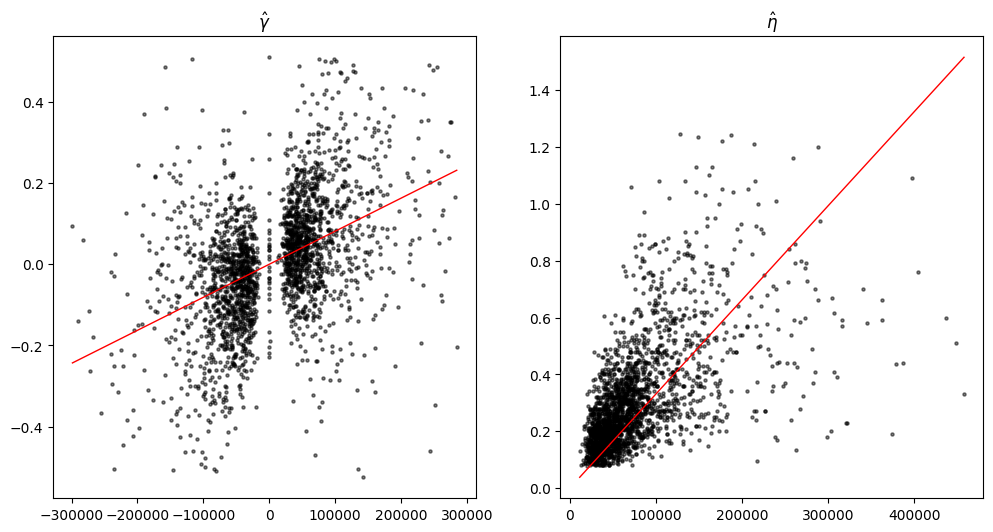

In [113]:
# -------------------------
# Graphes
# -------------------------
High = df[('High','AAPL')] 
Low = df[('Low','AAPL')] 
Close = df[('Close','AAPL')] 
Volume = df[('Volume','AAPL')] 

mid_price_proxy     = (High + Low) / 2
signed_volume_proxy = np.sign(Close.diff()) * Volume
range_price_proxy   = High - Low
delta_mid_price_proxy = mid_price_proxy.shift(-1) - mid_price_proxy

x_gamma = signed_volume_proxy
y_gamma = delta_mid_price_proxy

# Remove outliers (gamma)
qx_low, qx_high = x_gamma.quantile([0.01, 0.99])
qy_low, qy_high = y_gamma.quantile([0.01, 0.99])

mask_out = (
    (x_gamma > qx_low) & (x_gamma < qx_high) &
    (y_gamma > qy_low) & (y_gamma < qy_high)
)

x_gamma_clean = x_gamma[mask_out]
y_gamma_clean = y_gamma[mask_out]

denom_gamma = np.sum(x_gamma_clean**2)
gamma = np.sum(x_gamma_clean * y_gamma_clean) / denom_gamma if denom_gamma != 0 else 0.0

# ---------------------------------------------------------------------
# ETA (temporary impact proxy): range vs |q_t|
# ---------------------------------------------------------------------
x_eta = np.abs(signed_volume_proxy)
y_eta = range_price_proxy

# Remove outliers (eta)
qx_low_e, qx_high_e = x_eta.quantile([0.01, 0.99])
qy_low_e, qy_high_e = y_eta.quantile([0.01, 0.99])

mask_out_eta = (
    (x_eta > qx_low_e) & (x_eta < qx_high_e) &
    (y_eta > qy_low_e) & (y_eta < qy_high_e)
)

x_eta_clean = x_eta[mask_out_eta]
y_eta_clean = y_eta[mask_out_eta]

# -------------------------
# Récupération des paramètres 
# -------------------------
gamma, eta, sigma = calibration(High, Low, Close, Volume)

############################
######## Subplots ##########
############################
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# ---- Gamma plot ----
axes[0].scatter(x_gamma_clean, y_gamma_clean, color="black", s=5, alpha=0.5)
x_line = np.linspace(x_gamma_clean.min(), x_gamma_clean.max(), 200)
axes[0].plot(x_line, gamma * x_line, color="red", linewidth=1)
axes[0].set_title("$\hat{\gamma}$")

# ---- Eta plot ----
axes[1].scatter(x_eta_clean, y_eta_clean, color="black", s=5, alpha=0.5)
x_line_eta = np.linspace(x_eta_clean.min(), x_eta_clean.max(), 200)
axes[1].plot(x_line_eta, eta * x_line_eta, color="red", linewidth=1)
axes[1].set_title("$\hat{\eta}$")

plt.show()

In [114]:
delta = High.index[1] - High.index[0]
dt_seconds = delta.total_seconds()   # 60
tau = dt_seconds / (252 * 6.5 * 3600)
print(tau)

1.0175010175010176e-05


<a id='3'></a>
# 4. Almgren-Chriss implementation :

In [115]:
# =============================================================================
#                         ALMGREN-CHRISS MODEL
# =============================================================================

def sinh(x):
    """
    Hyperbolic sine helper.
    """
    return (np.exp(x) - np.exp(-x)) / 2.0


def optimal_vector(X, T, N, lam, gamma, eta, sigma):
    """
    Almgren–Chriss optimal liquidation schedule (discrete time).

    Parameters
    ----------
    X : float
        Initial inventory (shares to liquidate).
    T : float
        Total execution horizon (in years).
    N : int
        Number of intervals.
    lam : float
        Risk aversion parameter (lambda).
    gamma : float
        Permanent impact coefficient.
    eta : float
        Temporary impact coefficient.
    sigma : float
        Volatility (per sqrt year).

    Returns
    -------
    x : np.ndarray
        Inventory trajectory of size N+1.
    n : np.ndarray
        Trade list of size N.
    """

    # ------------------------------------------------------------------
    # Time step
    # ------------------------------------------------------------------
    tau = T / N

    # ------------------------------------------------------------------
    # Kappa parameter
    # ------------------------------------------------------------------
    kappa = np.sqrt((lam * sigma**2) / (eta - 0.5 * gamma * tau))

    # ------------------------------------------------------------------
    # Time grid
    # ------------------------------------------------------------------
    t = np.arange(N + 1) * tau

    # ------------------------------------------------------------------
    # Optimal inventory trajectory
    # ------------------------------------------------------------------
    x = X * sinh(kappa * (T - t)) / sinh(kappa * T)

    # ------------------------------------------------------------------
    # Trades
    # ------------------------------------------------------------------
    n = x[:-1] - x[1:]

    return x, n

<a id='4'></a>
# 5. Application :

**Cost of execution :**

$$
X S_0 - \sum_{k=1}^{N} n_k \tilde S_k
=
-\sum_{k=1}^{N}
\left(
\sigma \sqrt{\tau}\,\xi_k
-
\gamma n_k
\right) x_k
+
\sum_{k=1}^{N}
\left(
\epsilon\,|n_k|
+
\frac{\eta}{\tau} n_k^2
\right).
$$



In [116]:
# ==========================================================================
#                         Application / Simulation
# ==========================================================================

def simul_cost(N: int, n, x, sigma: float, T: float, gamma: float, eta: float, epsilon: float):
    '''
    Simulate one-path execution cost (implementation shortfall) in the
    Almgren–Chriss linear model, for a given trading schedule (x, n).

    We use the decomposition:
        Cost = - sum_k (sigma*sqrt(tau)*xi_k - gamma*n_k) * x_k
               + sum_k (epsilon*|n_k| + (eta/tau)*n_k^2)

    Notes
    -----
    - x is the inventory trajectory (length N+1)
    - n is the trade list (length N), with n_k = x_k - x_{k+1}
    - This function returns the cost for one Monte Carlo path.

    Inputs
    ------
    N : int
        Number of intervals.
    n : array-like, shape (N,)
        Trade list.
    x : array-like, shape (N+1,)
        Inventory trajectory.
    sigma, T, gamma, eta, epsilon : float
        Model parameters.

    Outputs
    -------
    cost : float
        Simulated execution cost for one path.
    '''

    # ------------------------------------------------------------------
    # Parameters
    # ------------------------------------------------------------------
    tau = T / N
    xi = np.random.randn(N)

    # ------------------------------------------------------------------
    # Vector of per-step contributions (k = 1..N uses x_k, here x[1:])
    # ------------------------------------------------------------------
    vect = (-(sigma * np.sqrt(tau) * xi) + gamma * n) * x[1:] \
           + epsilon * np.abs(n) \
           + (eta / tau) * n**2

    return float(np.sum(vect))

In [123]:
# ===================================================================
#                         Parameters
# ===================================================================

epsilon = 0.02              # Transaction cost proxy 
X = 500_000                  # Shares to liquidate
H = 120                     # Horizon in minutes (2 hours)
N = H                       # 1-min grid
T = H / (252 * 6.5 * 60)    # Horizon in years (consistent with annualized sigma)
S0 = 250.0                  # Approx AAPL price 

n_lam = 5                   # Number of lambdas to try
N_simul = 1_000             # Monte Carlo simulations per lambda

# Lambda
lam_grid = np.logspace(-8, -4, 5)

# -------------------------------------------------------------------
# Extract series from MultiIndex columns
# -------------------------------------------------------------------
High   = df[("High", "AAPL")]
Low    = df[("Low", "AAPL")]
Close  = df[("Close", "AAPL")]
Volume = df[("Volume", "AAPL")]

# -------------------------------------------------------------------
# Calibrate once (you said you only vary lambda)
# -------------------------------------------------------------------
gamma, eta, sigma = calibration(High, Low, Close, Volume)

# -------------------------------------------------------------------
# Monte Carlo costs for each lambda
# -------------------------------------------------------------------
matrix_cost = []

for lam in lam_grid:
    x, n = optimal_vector(X, T, N, lam, gamma, eta, sigma)

    cost = []
    for _ in range(N_simul):
        cost.append(simul_cost(N, n, x, sigma, T, gamma, eta, epsilon))

    matrix_cost.append(cost)

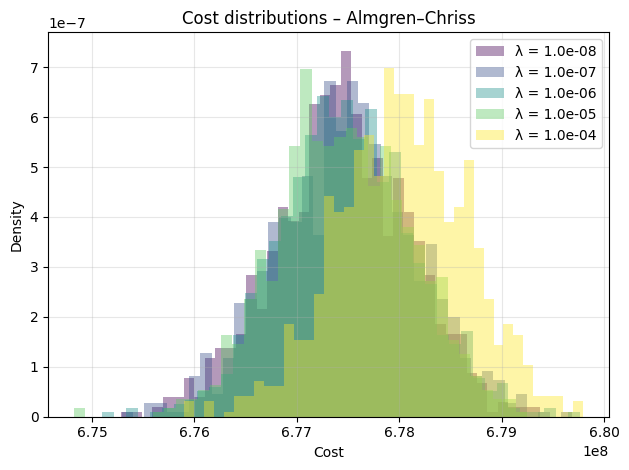

In [ ]:
plt.figure()

colors = plt.cm.viridis(np.linspace(0, 1, len(matrix_cost)))

for i, costs in enumerate(matrix_cost):
    plt.hist(
        costs,
        bins=40,
        alpha=0.4,                 
        color=colors[i],
        label=f"λ = {lam_grid[i]:.1e}",
        density=True        
    )

plt.xlabel("Cost")
plt.ylabel("Density")
plt.title("Cost distributions – Almgren–Chriss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()